# Healthcare Patient Analytics & Risk Analysis System

## Day 10 — Outlier Analysis

### Objective

Identify and analyze unusual observations in numerical healthcare
variables using the Interquartile Range (IQR) method.

Variables analyzed:

- Age
- Blood Pressure
- Heart Rate
- BMI
- Length of Stay
- Medication Count
- Treatment Cost
- Risk Score

Outliers will be investigated rather than automatically removed,
because extreme healthcare observations may represent genuine
patient conditions or high-cost cases.

In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load clean dataset
df = pd.read_csv("/content/cleaned_healthcare_patients.csv")

# verify
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Shape: (10000, 16)
Missing values: 0
Duplicate rows: 0


In [3]:
# Select Numerical Variable
numerical_columns = [
    "age",
    "blood_pressure",
    "heart_rate",
    "bmi",
    "length_of_stay",
    "medication_count",
    "treatment_cost",
    "risk_score"
]

In [5]:
# Calculate IQR bounds
def calculate_iqr_bounds(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    return q1, q3, iqr, lower_bound, upper_bound

calculate_iqr_bounds(df, "treatment_cost")

(np.float64(18765.25),
 np.float64(38821.25),
 np.float64(20056.0),
 np.float64(-11318.75),
 np.float64(68905.25))

In [7]:
# Calculate bounds for every variable
outlier_summary = []

for column in numerical_columns:
    q1, q3, iqr, lower_bound, upper_bound = calculate_iqr_bounds(
        df,
        column
    )

    outlier_count = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()

    outlier_percentage = (
        outlier_count / len(df)
    ) * 100

    outlier_summary.append({
        "Variable": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": outlier_count,
        "Outlier_Percentage": outlier_percentage
    })


outlier_summary_df = pd.DataFrame(outlier_summary)

outlier_summary_df.round(2)

,Variable,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
0,age,34.00,69.00,35.0,-18.50,121.50,0,0.00
1,blood_pressure,116.00,140.00,24.0,80.00,176.00,27,0.27
2,heart_rate,70.00,86.00,16.0,46.00,110.00,65,0.65
3,bmi,23.00,29.50,6.5,13.25,39.25,53,0.53
4,length_of_stay,4.00,8.00,4.0,-2.00,14.00,186,1.86
5,medication_count,1.00,4.00,3.0,-3.50,8.50,66,0.66
6,treatment_cost,18765.25,38821.25,20056.0,-11318.75,68905.25,195,1.95
7,risk_score,33.40,58.40,25.0,-4.10,95.90,71,0.71


In [10]:
# Find the variable with the most outliers
outlier_summary_df.sort_values(
    "Outlier_Count",
    ascending=False
)

,Variable,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
6,treatment_cost,18765.25,38821.25,20056.0,-11318.75,68905.25,195,1.95


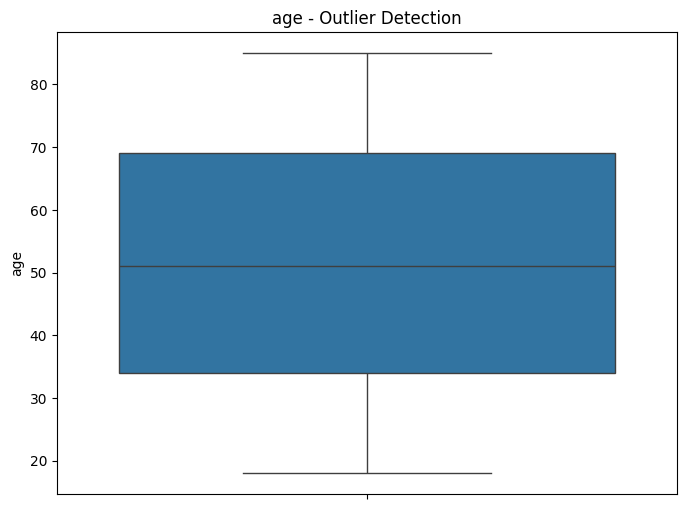

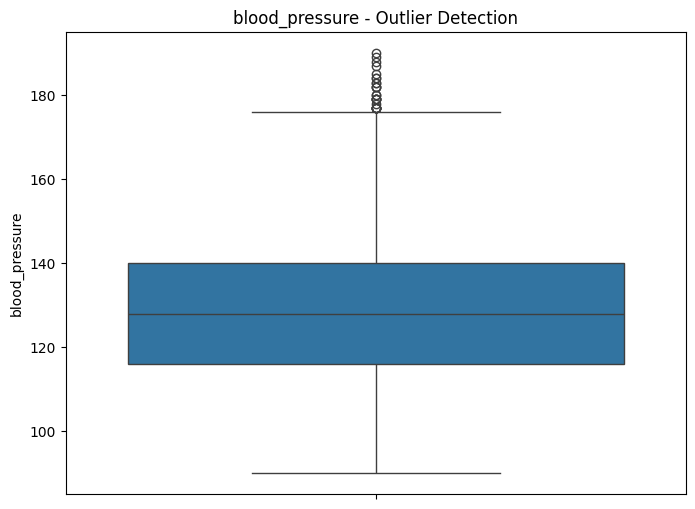

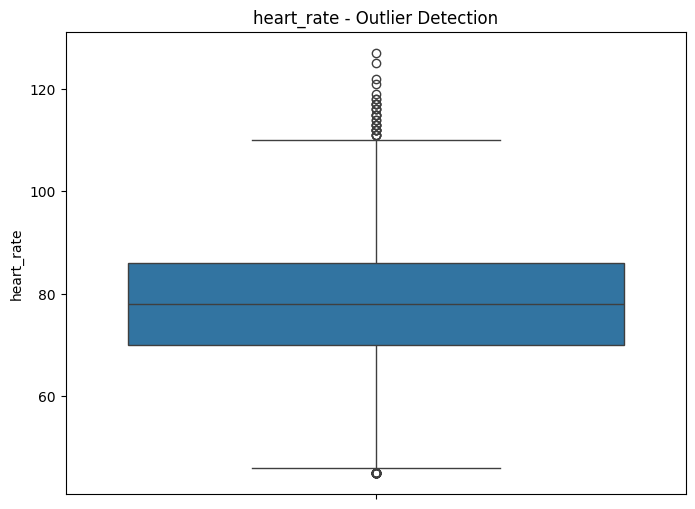

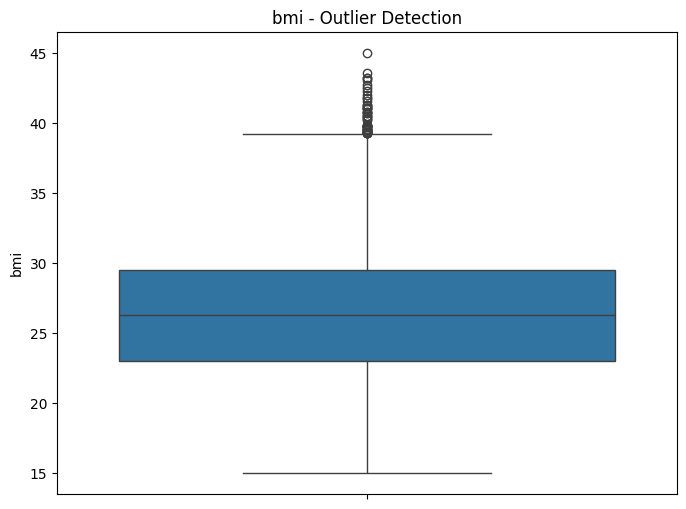

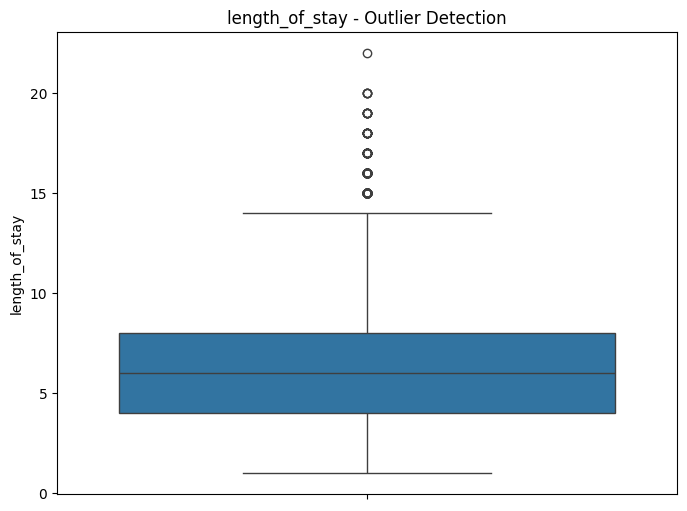

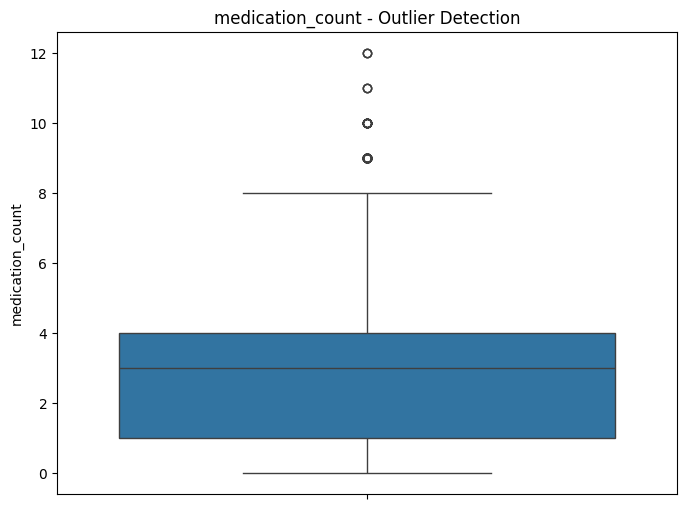

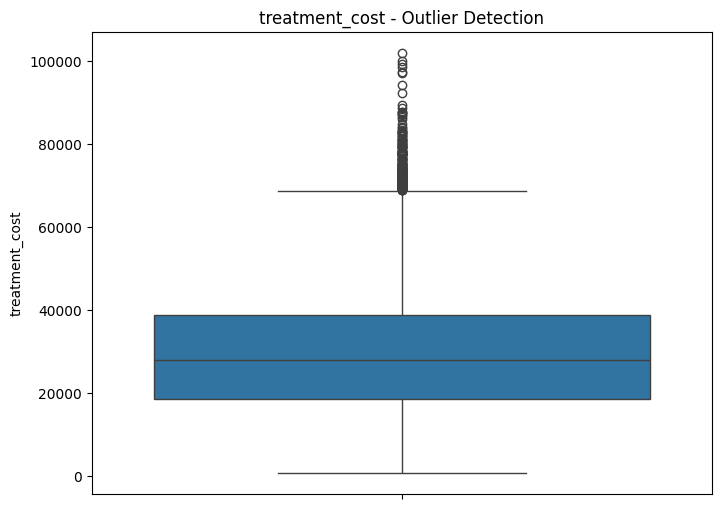

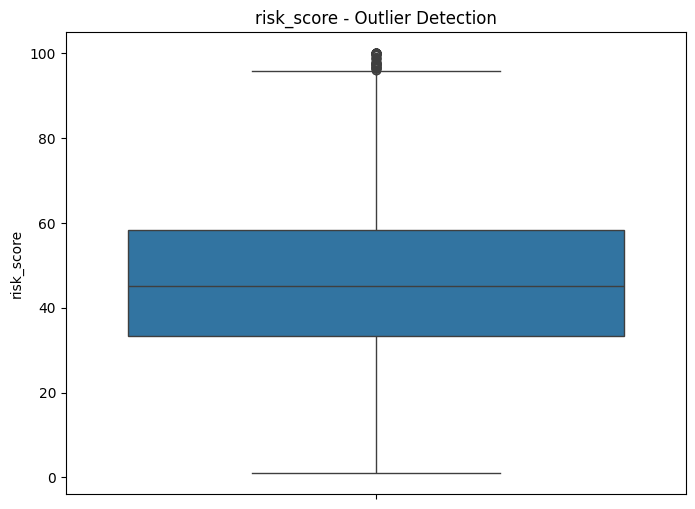

In [17]:
# Visualize outliers with boxplots
for column in numerical_columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df, y=column)
    plt.title(f"{column} - Outlier Detection")
    plt.ylabel(f"{column}")
    plt.show()

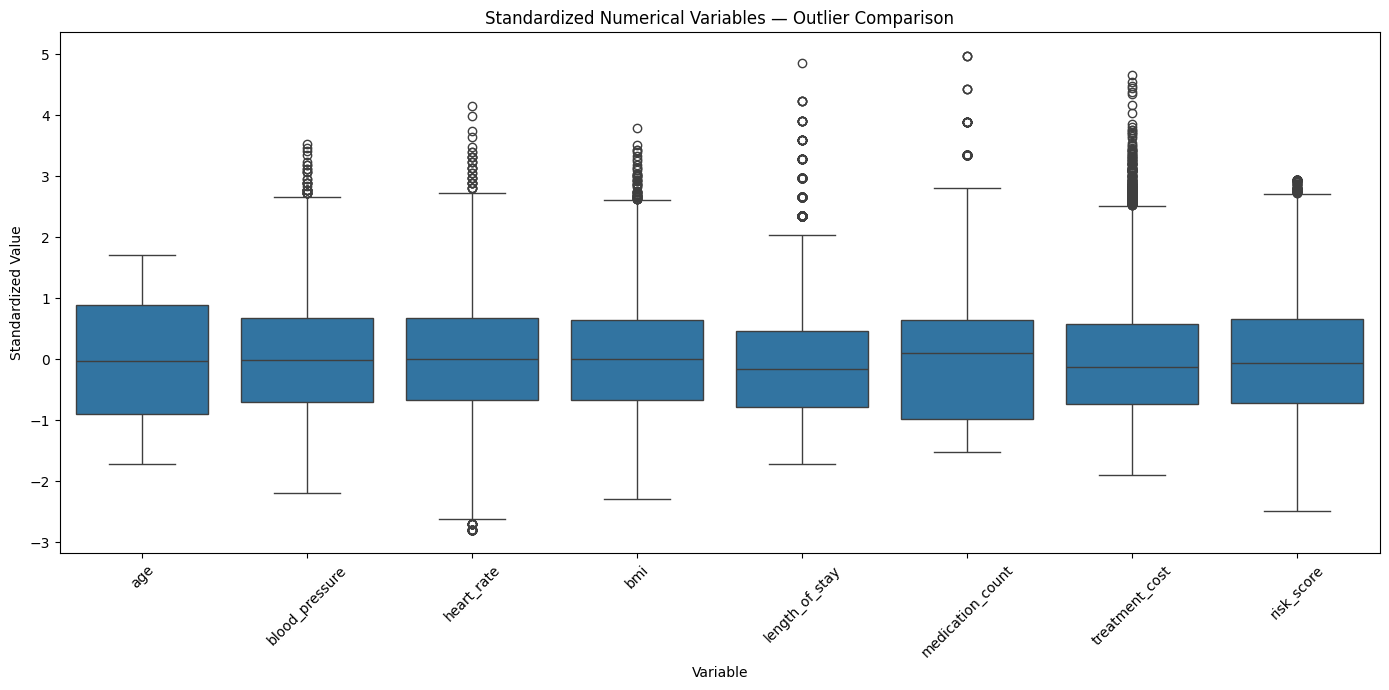

In [19]:
# Create a combined boxplot
scaled_df = df[numerical_columns].copy()

for column in numerical_columns:
    mean = scaled_df[column].mean()
    std = scaled_df[column].std()

    scaled_df[column] = (
        scaled_df[column] - mean
    ) / std

scaled_long = scaled_df.melt(
    var_name="Variable",
    value_name="Standardized_Value"
)

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=scaled_long,
    x="Variable",
    y="Standardized_Value"
)

plt.title("Standardized Numerical Variables — Outlier Comparison")
plt.xlabel("Variable")
plt.ylabel("Standardized Value")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [22]:
# Inspect treatment-cost outliers
q1, q3, iqr, lower_bound, upper_bound = calculate_iqr_bounds(
    df,
    "treatment_cost"
)

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

# Identify the records
treatment_cost_outliers = df[
    (df["treatment_cost"] < lower_bound) |
    (df["treatment_cost"] > upper_bound)
].copy()

print("Number of treatment cost outliers:",
      len(treatment_cost_outliers))

treatment_cost_outliers[
    [
        "patient_id",
        "age",
        "disease",
        "admission_type",
        "length_of_stay",
        "treatment_cost",
        "risk_score",
        "readmission"
    ]
].sort_values(
    "treatment_cost",
    ascending=False
).head(20)

Q1: 18765.25
Q3: 38821.25
IQR: 20056.0
Lower Bound: -11318.75
Upper Bound: 68905.25
Number of treatment cost outliers: 195


,patient_id,age,disease,admission_type,length_of_stay,treatment_cost,risk_score,readmission
4571,100121,59,Cancer,Emergency,20,101926.0,83.7,Yes
9665,107392,26,Cancer,Emergency,20,100116.0,73.7,Yes
5245,103751,58,Cancer,Emergency,19,99205.0,82.0,Yes
2350,107728,31,Cancer,Emergency,20,98586.0,57.8,Yes
2075,100674,35,Cancer,Elective,19,97462.0,56.1,No
6891,105156,73,Cancer,Emergency,17,97068.0,88.0,No
3081,109159,70,Cancer,Emergency,17,94209.0,97.0,Yes
779,101078,74,Cancer,Emergency,16,92289.0,86.9,No
1457,104375,28,Cancer,Emergency,16,89527.0,66.5,Yes
5599,105714,71,Heart Disease,Emergency,18,88708.0,95.5,Yes


In [23]:
# Inspect risk-score outliers
q1, q3, iqr, lower_bound, upper_bound = calculate_iqr_bounds(
    df,
    "risk_score"
)

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

risk_outliers = df[
    (df["risk_score"] < lower_bound) |
    (df["risk_score"] > upper_bound)
].copy()

risk_outliers[
    [
        "patient_id",
        "age",
        "disease",
        "admission_type",
        "treatment_cost",
        "risk_score",
        "readmission"
    ]
].sort_values(
    "risk_score",
    ascending=False
).head(20)

Q1: 33.4
Q3: 58.4
IQR: 25.0
Lower Bound: -4.100000000000001
Upper Bound: 95.9


,patient_id,age,disease,admission_type,treatment_cost,risk_score,readmission
214,103803,70,Cancer,Emergency,67508.0,100.0,No
534,109392,84,Cancer,Emergency,69920.0,100.0,No
674,102525,64,Heart Disease,Emergency,56450.0,100.0,No
866,105818,65,Kidney Disease,Emergency,47241.0,100.0,Yes
797,105850,65,Heart Disease,Emergency,50765.0,100.0,Yes
2574,105132,82,Cancer,Emergency,86560.0,100.0,No
899,109532,85,Cancer,Emergency,62389.0,100.0,No
7222,102005,68,Cancer,Elective,82952.0,100.0,Yes
7769,106327,79,Cancer,Emergency,77990.0,100.0,No
2361,106384,81,Cancer,Urgent,71826.0,100.0,No


In [24]:
# Compare outliers with disease
cost_outlier_by_disease = (
    treatment_cost_outliers
    .groupby("disease")
    .size()
    .sort_values(ascending=False)
)

cost_outlier_by_disease

cost_outlier_percentage = (
    treatment_cost_outliers["disease"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

cost_outlier_percentage

,proportion
disease,
Cancer,77.95
Heart Disease,15.38
Kidney Disease,4.10
Respiratory Disease,1.54
Other,1.03


In [ ]:
# Compare outliers with admission type
cost_outlier_by_admission = (
    treatment_cost_outliers
    .groupby("admission_type")
    .size()
    .sort_values(ascending=False)
)

cost_outlier_by_admission

In [ ]:
# Compare treatment-cost outliers and readmission
cost_outlier_by_readmission = (
    treatment_cost_outliers
    .groupby("readmission")
    .size()
)

cost_outlier_by_readmission

cost_outlier_by_readmission_percentage = (
    treatment_cost_outliers["readmission"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

cost_outlier_by_readmission_percentage

## Day 10 — Outlier Analysis Observations

### 1. Overall Outlier Distribution

The IQR method was applied to eight numerical variables.

Treatment Cost had the highest number of detected potential outliers,
with 195 observations (1.95% of the dataset).

Length of Stay had 186 potential outliers (1.86%).

The remaining variables had relatively small proportions of potential
outliers:

- Blood Pressure: 27 (0.27%)
- Heart Rate: 65 (0.65%)
- BMI: 53 (0.53%)
- Medication Count: 66 (0.66%)
- Risk Score: 71 (0.71%)
- Age: 0 (0.00%)

### 2. Treatment Cost

The treatment-cost IQR was ₹20,056.00, with an upper IQR boundary
of ₹68,905.25.

The IQR method identified 195 treatment-cost observations above this
boundary.

The lower IQR boundary was negative, so the detected treatment-cost
outliers are effectively high-cost observations.

These records should not automatically be removed because high
healthcare costs may represent genuine complex or severe cases.

### 3. Risk Score

The risk-score IQR was 25.0, producing an upper IQR boundary of
95.9.

The analysis identified 71 potential high-risk-score outliers.

These observations represent unusually high risk scores according to
the IQR method and should be investigated rather than automatically
removed.

### 4. Length of Stay

Length of stay had an upper IQR boundary of 14 days and 186 potential
outliers.

These observations represent unusually long hospital stays according
to the IQR method.

Long hospital stays may be legitimate healthcare observations rather
than data errors.

### 5. Other Numerical Variables

Blood pressure, heart rate, BMI, and medication count contained
relatively small proportions of potential outliers.

The presence of an IQR outlier does not automatically indicate an
incorrect value.

### 6. Outlier Handling Decision

Potential outliers were retained in the cleaned dataset.

This decision was made because extreme healthcare observations may
represent genuine patient conditions, complex treatments, high-risk
patients, or extended hospital stays.

Therefore, outlier detection was treated as an analytical step rather
than an automatic data-cleaning step.